## Optimización Bajo Incertidumbre (IIND 4125)

### Proyecto 2: Programación Estocástica

#### Daniel Velandia, Juan Aguirre y Sofía Acosta

In [90]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [91]:
# Parámetros principales del modelo
SEED_BASE = 123
INSTANCE = 1
DELTA_U = 0.8 # incremento de capacidad si se refuerza una línea
H_VALUE = 50 # costo de reforzar cada arco
BUDGET = 2500 # presupuesto total
PI = 190 # penalización por energía no servida
ALPHA = 0.95 # nivel CVaR

## 1. Generación de escenarios

In [92]:
# Carga de la red base

def load_edges_from_csv(path_edges: str):
    edges = pd.read_csv(path_edges)
    edges = edges.rename(columns={
        "node_id1": "i",
        "node_id2": "j",
        "b": "c_base",
        "f_max": "U_base"
    })
    edges["e_id"] = np.arange(len(edges))
    return edges

def load_nodes_from_csv(path_nodes: str):
    nodes = pd.read_csv(path_nodes)
    nodes = nodes.rename(columns={"node_id": "node"})
    return nodes

edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)

#print("Instancia:", INSTANCE)
print("Nodos:", len(nodes))
print("Arcos:", len(edges))
print("Generadores:", nodes["is_generator"].sum())

Nodos: 118
Arcos: 179
Generadores: 18


In [93]:
def build_base_data(nodes, edges):
    nodes_list = nodes["node"].unique().tolist()
    edges_list = edges["e_id"].unique().tolist()

    demand_nodes = nodes[nodes["d"].fillna(0) > 0]["node"].tolist()
    gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

    out_arcs = {
        i: edges[edges["i"] == i]["e_id"].tolist()
        for i in nodes_list
    }

    in_arcs = {
        i: edges[edges["j"] == i]["e_id"].tolist()
        for i in nodes_list
    }

    arc_i = dict(zip(edges["e_id"], edges["i"]))
    arc_j = dict(zip(edges["e_id"], edges["j"]))

    U_base = dict(zip(edges["e_id"], edges["U_base"]))
    H_e = {e: H_VALUE for e in edges_list}

    return {
        "nodes_list": nodes_list,
        "edges_list": edges_list,
        "demand_nodes": demand_nodes,
        "gen_nodes": gen_nodes,
        "in_arcs": in_arcs,
        "out_arcs": out_arcs,
        "arc_i": arc_i,
        "arc_j": arc_j,
        "U_base": U_base,
        "H_e": H_e
    }


base = build_base_data(nodes, edges)

print("Nodos de demanda:", len(base["demand_nodes"]))
print("Nodos generadores:", len(base["gen_nodes"]))
print("Arcos:", len(base["edges_list"]))

Nodos de demanda: 89
Nodos generadores: 18
Arcos: 179


In [94]:
# Generador de escenarios
def sample_one_scenario_W(
    nodes, edges, rng,
    p_crisis=0.15,
    dem_sigma=0.10,
    cost_sigma=0.05,
    p_outage=0.20,
    cap_drop=0.45,
    crisis_cost_mult=1.25,
    correlated_outage_nodes=None,
    correlated_outage_prob=0.80
):
    crisis = rng.random() < p_crisis

    # Demanda
    D = nodes[["node"]].copy()
    D["D_base"] = nodes["d"].fillna(0.0)

    if not crisis:
        mult = rng.normal(1.0, dem_sigma, size=len(D))
        mult = np.clip(mult, 0.0, None)
    else:
        pareto_alpha = 2.0
        mult = 1.0 + rng.pareto(a=pareto_alpha, size=len(D))

    D["D_w"] = D["D_base"] * mult
    D.loc[D["D_base"] == 0, "D_w"] = 0.0

    # Costos operativos
    c = edges[["e_id", "c_base"]].copy()

    if not crisis:
        cost_mult = rng.normal(1.0, cost_sigma, size=len(c))
        cost_mult = np.clip(cost_mult, 0.1, None)
    else:
        cost_mult = np.ones(len(c)) * crisis_cost_mult

    c["c_w"] = c["c_base"] * cost_mult

    # Capacidad efectiva
    U = edges[["e_id", "i", "j", "U_base"]].copy()
    U["U_w"] = U["U_base"]

    outage = rng.random(len(U)) < p_outage
    U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]

    if crisis and correlated_outage_nodes is not None:
        for node in correlated_outage_nodes:
            if rng.random() < correlated_outage_prob:
                mask = (U["i"] == node) | (U["j"] == node)
                U.loc[mask, "U_w"] = 0.0

    # Generación disponible
    G = nodes[["node", "p_max", "is_generator"]].copy()
    G["G_w"] = np.where(G["is_generator"] == True, G["p_max"].fillna(0.0), 0.0)

    if crisis:
        G["G_w"] = 0.85 * G["G_w"]

    return {
        "D": D[["node", "D_w"]],
        "U": U[["e_id", "U_w"]],
        "c": c[["e_id", "c_w"]],
        "G": G[["node", "G_w"]],
        "crisis": crisis
    }

In [95]:
def generate_scenarios_table(nodes, edges, N, seed=123):
    rng = np.random.default_rng(seed)

    gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

    scenarios = []
    for _ in range(N):
        sc = sample_one_scenario_W(
            nodes,
            edges,
            rng,
            correlated_outage_nodes=gen_nodes
        )
        scenarios.append(sc)

    rows_D, rows_U, rows_c, rows_G, rows_p = [], [], [], [], []

    p = 1.0 / N

    for w, sc in enumerate(scenarios, start=1):
        rows_p.append({
            "omega": w,
            "p_omega": p,
            "crisis": sc["crisis"]
        })

        for _, r in sc["D"].iterrows():
            rows_D.append({
                "omega": w,
                "node": int(r["node"]),
                "D_iw": float(r["D_w"])
            })

        for _, r in sc["U"].iterrows():
            rows_U.append({
                "omega": w,
                "e_id": int(r["e_id"]),
                "U_ew": float(r["U_w"])
            })

        for _, r in sc["c"].iterrows():
            rows_c.append({
                "omega": w,
                "e_id": int(r["e_id"]),
                "c_ew": float(r["c_w"])
            })

        for _, r in sc["G"].iterrows():
            rows_G.append({
                "omega": w,
                "node": int(r["node"]),
                "G_iw": float(r["G_w"])
            })

    return (
        pd.DataFrame(rows_D),
        pd.DataFrame(rows_U),
        pd.DataFrame(rows_c),
        pd.DataFrame(rows_G),
        pd.DataFrame(rows_p)
    )

In [96]:
def build_scenario_data(dfD, dfU, dfc, dfG, dfp):
    omegas = dfp["omega"].tolist()

    p_omega = dict(zip(dfp["omega"], dfp["p_omega"]))

    D = {
        (int(r.omega), int(r.node)): float(r.D_iw)
        for _, r in dfD.iterrows()
    }

    U_ew = {
        (int(r.omega), int(r.e_id)): float(r.U_ew)
        for _, r in dfU.iterrows()
    }

    c_ew = {
        (int(r.omega), int(r.e_id)): float(r.c_ew)
        for _, r in dfc.iterrows()
    }

    G_iw = {
        (int(r.omega), int(r.node)): float(r.G_iw)
        for _, r in dfG.iterrows()
    }

    return omegas, p_omega, D, U_ew, c_ew, G_iw

In [97]:
# Prueba escenarios variando N
N_TEST = 10

dfD, dfU, dfc, dfG, dfp = generate_scenarios_table(
    nodes,
    edges,
    N=N_TEST,
    seed=SEED_BASE
)

omegas, p_omega, D, U_ew, c_ew, G_iw = build_scenario_data(
    dfD, dfU, dfc, dfG, dfp
)

print("Escenarios generados:", len(omegas))
print("Suma de probabilidades:", sum(p_omega.values()))
print("Escenarios de crisis:", dfp["crisis"].sum())

C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[575.55 132.75 121.95 127.8  121.95 150.3  143.1   92.25 142.2  141.75
 128.7  121.95 121.5  113.4  136.8  113.4  150.3  142.2  556.2  150.3
 113.85 113.85 121.95 142.2  113.4  100.35 130.05 111.6  142.2  621.9 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[142.2  142.2  121.95 132.75 116.55 143.1  121.95 141.75 121.95  94.5
 122.85 121.5  136.8  125.55 113.4   90.45 240.3  142.2   58.05 113.85
 121.95 140.85 141.75 113.85 121.5  121.95 113.4  109.35 121.95 890.1
 615.6  642.15 113.85]' has dtype in

Escenarios generados: 10
Suma de probabilidades: 0.9999999999999999
Escenarios de crisis: 1


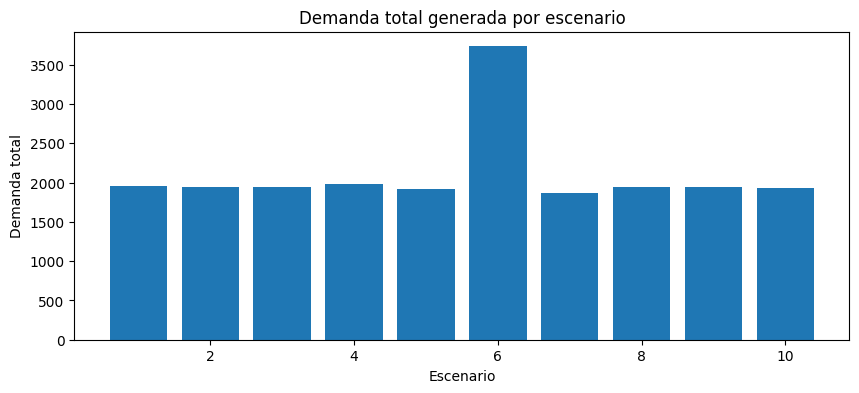

In [98]:
# Comparación de escenarios generados

# Demanda
demanda_total = dfD.groupby("omega")["D_iw"].sum().reset_index()
demanda_total = demanda_total.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(demanda_total["omega"], demanda_total["D_iw"])
plt.title("Demanda total generada por escenario")
plt.xlabel("Escenario")
plt.ylabel("Demanda total")
plt.show()

<Figure size 600x400 with 0 Axes>

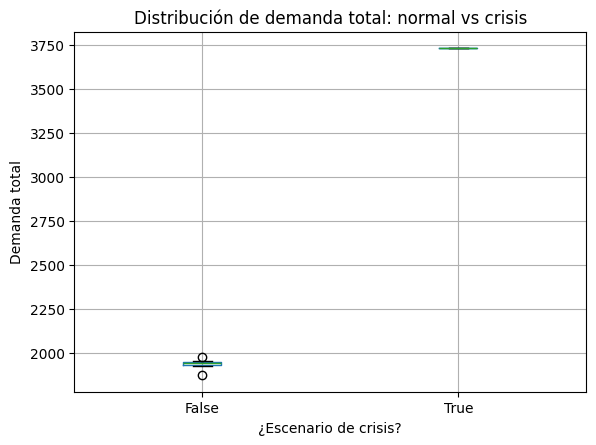

In [99]:
plt.figure(figsize=(6,4))
demanda_total.boxplot(column="D_iw", by="crisis")
plt.title("Distribución de demanda total: normal vs crisis")
plt.suptitle("")
plt.xlabel("¿Escenario de crisis?")
plt.ylabel("Demanda total")
plt.show()

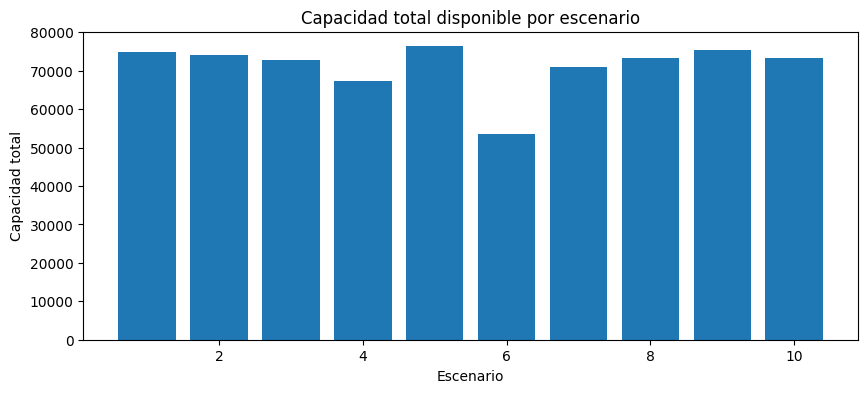

In [100]:
capacidad_total = dfU.groupby("omega")["U_ew"].sum().reset_index()
capacidad_total = capacidad_total.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(capacidad_total["omega"], capacidad_total["U_ew"])
plt.title("Capacidad total disponible por escenario")
plt.xlabel("Escenario")
plt.ylabel("Capacidad total")
plt.show()

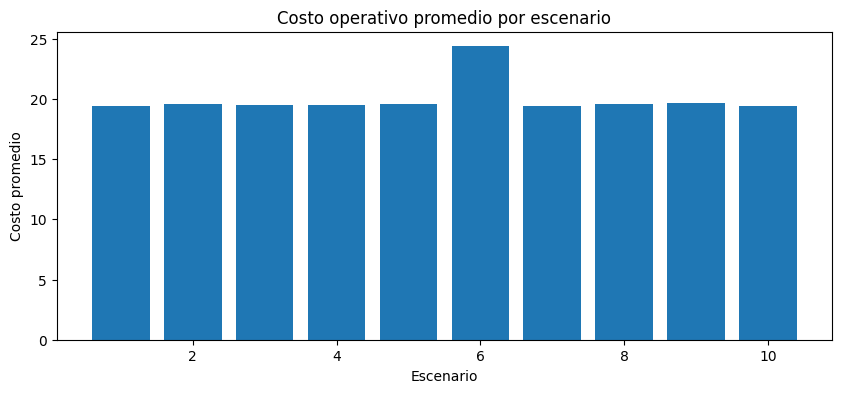

In [101]:
costo_promedio = dfc.groupby("omega")["c_ew"].mean().reset_index()
costo_promedio = costo_promedio.merge(dfp, on="omega")

plt.figure(figsize=(10,4))
plt.bar(costo_promedio["omega"], costo_promedio["c_ew"])
plt.title("Costo operativo promedio por escenario")
plt.xlabel("Escenario")
plt.ylabel("Costo promedio")
plt.show()

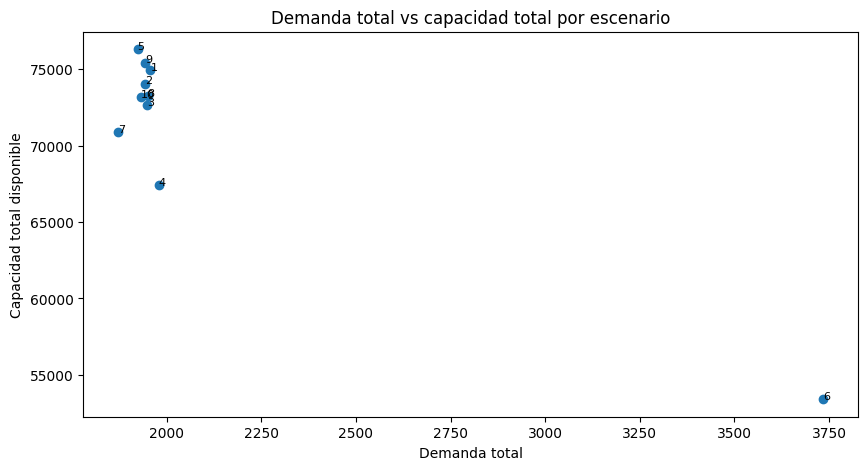

In [102]:
resumen = demanda_total[["omega", "D_iw", "crisis"]].merge(
    capacidad_total[["omega", "U_ew"]],
    on="omega"
)

plt.figure(figsize=(10,5))
plt.scatter(resumen["D_iw"], resumen["U_ew"])

for _, row in resumen.iterrows():
    plt.text(row["D_iw"], row["U_ew"], str(int(row["omega"])), fontsize=8)

plt.title("Demanda total vs capacidad total por escenario")
plt.xlabel("Demanda total")
plt.ylabel("Capacidad total disponible")
plt.show()

In [103]:
resumen["gap_demanda_capacidad"] = resumen["D_iw"] - resumen["U_ew"]

resumen.sort_values("gap_demanda_capacidad", ascending=False)

,omega,D_iw,crisis,U_ew,gap_demanda_capacidad
5,6,3733.559752,True,53403.80,-49670.240248
3,4,1978.934654,False,67427.15,-65448.215346
6,7,1872.883426,False,70885.55,-69012.666574
2,3,1949.060826,False,72647.75,-70698.689174
9,10,1932.285055,False,73167.50,-71235.214945
7,8,1950.122791,False,73246.15,-71296.027209
1,2,1943.299106,False,74054.10,-72110.800894
0,1,1957.299204,False,74929.70,-72972.400796
8,9,1943.138213,False,75422.50,-73479.361787
4,5,1923.418109,False,76316.25,-74392.831891


## 2. Componente algorítmico: tres estrategias de solución

En esta sección se comparan tres estrategias para resolver el mismo problema estocástico de dos etapas:

1. **Equivalente determinístico (DE):** resuelve la formulación extensiva completa en un solo modelo.
2. **Benders naive:** separa el problema en un master problem de primera etapa y subproblemas de segunda etapa por escenario.
3. **Branch-and-Cut con callbacks:** incorpora los cortes de Benders dentro del árbol de Branch & Bound de Gurobi usando lazy constraints.

El objetivo de esta comparación es analizar si las técnicas de descomposición permiten resolver el problema de forma más eficiente que la formulación extensiva.

## 2.1. Modelo equivalente determinístico

In [104]:
def solve_deterministic_equivalent(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    time_limit=None,
    verbose=True
):
    start = time.time()

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    m = gp.Model("Deterministic_Equivalent")

    if not verbose:
        m.Params.OutputFlag = 0

    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # Variables de primera etapa
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")

    # Variables de segunda etapa
    f = m.addVars(omegas, edges_list, lb=0, name="f")
    delta = m.addVars(omegas, demand_nodes, lb=0, name="delta")
    g = m.addVars(omegas, gen_nodes, lb=0, name="g")

    # Presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Restricciones por escenario
    for w in omegas:

        # Capacidad de arcos
        for e in edges_list:
            m.addConstr(
                f[w, e] <= U_ew[w, e] * (1 + delta_u * h[e]),
                name=f"cap_w{w}_e{e}"
            )

        # Límite generación
        for i in gen_nodes:
            m.addConstr(
                g[w, i] <= G_iw[w, i],
                name=f"gen_w{w}_i{i}"
            )

        # Límite demanda no servida
        for i in demand_nodes:
            m.addConstr(
                delta[w, i] <= D[w, i],
                name=f"delta_w{w}_i{i}"
            )

        # Balance de flujo
        for i in nodes_list:

            inflow = gp.quicksum(f[w, e] for e in in_arcs[i])
            outflow = gp.quicksum(f[w, e] for e in out_arcs[i])

            if i in demand_nodes:
                m.addConstr(
                    inflow - outflow == D[w, i] - delta[w, i],
                    name=f"balance_demand_w{w}_i{i}"
                )

            elif i in gen_nodes:
                m.addConstr(
                    inflow - outflow == -g[w, i],
                    name=f"balance_gen_w{w}_i{i}"
                )

            else:
                m.addConstr(
                    inflow - outflow == 0,
                    name=f"balance_trans_w{w}_i{i}"
                )

    # Función objetivo
    investment_cost = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    expected_operating_cost = gp.quicksum(
        p_omega[w] * gp.quicksum(c_ew[w, e] * f[w, e] for e in edges_list)
        for w in omegas
    )

    expected_ens_cost = gp.quicksum(
        p_omega[w] * pi * gp.quicksum(delta[w, i] for i in demand_nodes)
        for w in omegas
    )

    m.setObjective(
        investment_cost + expected_operating_cost + expected_ens_cost,
        GRB.MINIMIZE
    )

    m.optimize()

    runtime = time.time() - start

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Estado del modelo:", m.Status)
        return None

    h_sol = {e: h[e].X for e in edges_list}

    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    results = {
        "model": m,
        "objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "investment_cost": sum(H_e[e] * h_sol[e] for e in edges_list),
        "num_selected_edges": len(selected_edges)
    }

    return results

In [105]:

# Modelo con datos de prueba
de_results = solve_deterministic_equivalent(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    verbose=True
)

print("Objetivo DE:", de_results["objective"])
print("Tiempo:", de_results["runtime"])
print("Costo inversión:", de_results["investment_cost"])
print("Arcos reforzados:", de_results["num_selected_edges"])
print("Lista de arcos reforzados:", de_results["selected_edges"])

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 5600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 4041 rows, 3039 columns and 9425 nonzeros
Model fingerprint: 0x8bb5a572
Variable types: 2860 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [2e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]
Found heuristic solution: objective 402496.02159
Presolve removed 3208 rows and 1662 columns
Presolve time: 0.07s
Presolved: 833 rows, 1377 columns, 3438 nonzeros
Found heuristic solution: objective 336192.74450
Variable types: 1288 continuous, 89 integer (89 binary)
Found heuristic solution: objective 336170.75530

Root relaxation: objective 1.826976e+05, 339 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |

In [106]:
edges_plot = edges.copy()
edges_plot["reforzado"] = edges_plot["e_id"].isin(de_results["selected_edges"])

edges_plot[["e_id", "i", "j", "U_base", "reforzado"]].sort_values(
    "reforzado",
    ascending=False
)

,e_id,i,j,U_base,reforzado
94,94,48,68,156,True
17,17,13,14,259,True
93,93,46,68,183,True
48,48,36,39,252,True
69,69,48,53,178,True
...,...,...,...,...,...
65,65,48,50,252,False
66,66,50,51,255,False
67,67,51,52,298,False
68,68,52,53,318,False


In [108]:
def extract_scenario_costs_from_de(de_results, base, omegas, p_omega, c_ew, pi=PI):
    m = de_results["model"]

    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]

    rows = []

    for w in omegas:
        op_cost = 0
        ens_cost = 0

        for e in edges_list:
            var = m.getVarByName(f"f[{w},{e}]")
            op_cost += c_ew[w, e] * var.X

        for i in demand_nodes:
            var = m.getVarByName(f"delta[{w},{i}]")
            ens_cost += pi * var.X

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "operating_cost": op_cost,
            "ens_cost": ens_cost,
            "second_stage_cost": op_cost + ens_cost
        })

    return pd.DataFrame(rows)


df_costs_de = extract_scenario_costs_from_de(
    de_results,
    base,
    omegas,
    p_omega,
    c_ew
)

df_costs_de

,omega,p_omega,operating_cost,ens_cost,second_stage_cost
0,1,0.1,62216.648053,66371.309477,128587.957531
1,2,0.1,62547.835965,71434.599035,133982.435000
2,3,0.1,65728.017988,72807.172739,138535.190727
3,4,0.1,65391.624186,77410.549294,142802.173480
4,5,0.1,61646.973188,70205.293030,131852.266218
5,6,0.1,57491.894944,553013.604155,610505.499100
6,7,0.1,61089.338110,71007.856089,132097.194200
7,8,0.1,63304.315357,71866.309053,135170.624410
8,9,0.1,66999.153276,69551.243260,136550.396536
9,10,0.1,62305.565038,70097.215501,132402.780539


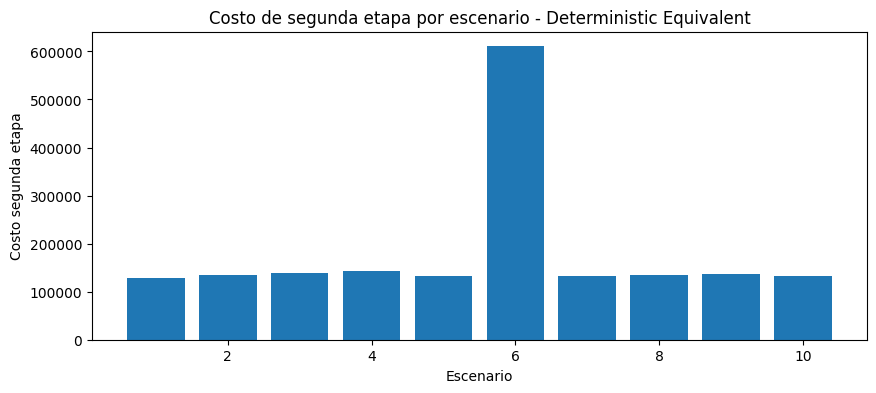

In [109]:
df_costs_plot = df_costs_de.merge(dfp[["omega", "crisis"]], on="omega")

plt.figure(figsize=(10,4))
plt.bar(df_costs_plot["omega"], df_costs_plot["second_stage_cost"])
plt.title("Costo de segunda etapa por escenario - Deterministic Equivalent")
plt.xlabel("Escenario")
plt.ylabel("Costo segunda etapa")
plt.show()

## 2.2. Benders Naive

In [110]:
def solve_second_stage(w, h_hat, base, D, U_ew, c_ew, G_iw,
                       delta_u=DELTA_U, pi=PI, verbose=False):
    """
    Resuelve el subproblema de segunda etapa para un escenario fijo w
    y una decisión de inversión h_hat.

    Retorna:
        - objective: costo óptimo de segunda etapa Q_w(h_hat)
        - dual_cap: diccionario con los multiplicadores duales asociados
                    a las restricciones de capacidad de cada arco.
        - operating_cost, ens_cost: desglose de costos
        - delta: diccionario {nodo: demanda no servida} (solo nodos de demanda)
        - generation: diccionario {nodo: generación utilizada} (solo nodos generadores)
    """
    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]

    sp = gp.Model(f"SP_w{w}")
    if not verbose:
        sp.Params.OutputFlag = 0

    f = sp.addVars(edges_list, lb=0, name="f")
    delta = sp.addVars(demand_nodes, lb=0, name="delta")
    g = sp.addVars(gen_nodes, lb=0, name="g")

    # Restricciones de capacidad (con duales)
    cap_constr = {}
    for e in edges_list:
        cap_constr[e] = sp.addConstr(
            f[e] <= U_ew[w, e] * (1 + delta_u * h_hat[e]),
            name=f"cap_e{e}"
        )

    for i in gen_nodes:
        sp.addConstr(g[i] <= G_iw[w, i], name=f"gen_i{i}")
    for i in demand_nodes:
        sp.addConstr(delta[i] <= D[w, i], name=f"delta_i{i}")

    # Balance de flujo
    for i in nodes_list:
        inflow = gp.quicksum(f[e] for e in in_arcs[i])
        outflow = gp.quicksum(f[e] for e in out_arcs[i])
        if i in demand_nodes:
            sp.addConstr(inflow - outflow == D[w, i] - delta[i],
                         name=f"balance_demand_i{i}")
        elif i in gen_nodes:
            sp.addConstr(inflow - outflow == -g[i],
                         name=f"balance_gen_i{i}")
        else:
            sp.addConstr(inflow - outflow == 0,
                         name=f"balance_trans_i{i}")

    operating_cost = gp.quicksum(c_ew[w, e] * f[e] for e in edges_list)
    ens_cost = pi * gp.quicksum(delta[i] for i in demand_nodes)
    sp.setObjective(operating_cost + ens_cost, GRB.MINIMIZE)

    sp.optimize()
    if sp.Status != GRB.OPTIMAL:
        print(f"Subproblema escenario {w} no óptimo. Status: {sp.Status}")
        return None

    Q_w = sp.ObjVal
    dual_cap = {e: cap_constr[e].Pi for e in edges_list}

    # Obtener valores de las variables (necesarios para evaluate_solution)
    delta_sol = {i: delta[i].X for i in demand_nodes}
    g_sol = {i: g[i].X for i in gen_nodes}

    return {
        "objective": Q_w,
        "dual_cap": dual_cap,
        "operating_cost": sum(c_ew[w, e] * f[e].X for e in edges_list),
        "ens_cost": pi * sum(delta[i].X for i in demand_nodes),
        "delta": delta_sol,
        "generation": g_sol
    }

In [111]:
def evaluate_solution(
    h_hat,
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    pi=PI,
    verbose=False
):
    """
    Evalúa una solución fija h_hat en todos los escenarios.

    Retorna:
    - costo total esperado,
    - costo de inversión,
    - costo esperado de segunda etapa,
    - costos por escenario.
    """

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    # Calculamos el costo fijo de inversión
    investment_cost = sum(H_e[e] * h_hat[e] for e in edges_list)

    rows = []
    expected_second_stage = 0

    # Evaluamos cada escenario
    for w in omegas:

        sp_res = solve_second_stage(
            w=w,
            h_hat=h_hat,
            base=base,
            D=D,
            U_ew=U_ew,
            c_ew=c_ew,
            G_iw=G_iw,
            delta_u=delta_u,
            pi=pi,
            verbose=verbose
        )

        Q_w = sp_res["objective"]

        # Costo esperado ponderado por probabilidad del escenario
        expected_second_stage += p_omega[w] * Q_w

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "second_stage_cost": Q_w,
            "operating_cost": sp_res["operating_cost"],
            "ens_cost": sp_res["ens_cost"],
            "total_cost_scenario": investment_cost + Q_w,
            "total_deficit": sum(sp_res["delta"].values())
        })

    total_expected_cost = investment_cost + expected_second_stage

    return {
        "total_expected_cost": total_expected_cost,
        "investment_cost": investment_cost,
        "expected_second_stage": expected_second_stage,
        "scenario_costs": pd.DataFrame(rows)
    }

In [112]:
def add_combinatorial_cut(
    model,
    z_var,
    h_vars,
    h_hat,
    Q_hat,
    edges_list,
    name="comb_cut"
):
    """
    Agrega un corte combinatorio de Benders.

    El corte obliga a que:
    - Si h es igual a h_hat, entonces z >= Q_hat.
    - Si h es diferente, el corte se relaja y no afecta demasiado al modelo.

    Este tipo de corte es útil cuando las variables de primera etapa son binarias.
    """

    # Arcos que estaban reforzados en h_hat
    ones = [e for e in edges_list if h_hat[e] >= 0.5]

    # Arcos que no estaban reforzados en h_hat
    zeros = [e for e in edges_list if h_hat[e] < 0.5]

    # Esta expresión vale 1 cuando h es exactamente igual a h_hat.
    # Si h cambia, la expresión baja a 0 o valores negativos.
    expr = 1

    # Penaliza cambios en arcos que antes eran 1
    expr -= gp.quicksum(1 - h_vars[e] for e in ones)

    # Penaliza cambios en arcos que antes eran 0
    expr -= gp.quicksum(h_vars[e] for e in zeros)

    # Corte combinatorio
    model.addConstr(
        z_var >= Q_hat * expr,
        name=name
    )

In [113]:
def solve_benders_naive(base, omegas, p_omega, D, U_ew, c_ew, G_iw,
                        delta_u=DELTA_U, budget=BUDGET, pi=PI,
                        max_iter=100, tol=1e-4, time_limit=None, verbose=True):
    """
    Algoritmo de Benders desagregado (naive) con cortes de optimalidad clásicos.
    - El master problema decide las inversiones h_e y variables auxiliares z_w.
    - Los subproblemas se resuelven para cada escenario y devuelven Q_w y duales.
    - Se agrega un corte de Benders por cada escenario donde z_w subestima Q_w.
    """
    start_time = time.time()
    edges_list = base["edges_list"]
    H_e = base["H_e"]

    # ----- Master problem -----
    master = gp.Model("Benders_Naive")
    master.Params.OutputFlag = 0
    if time_limit is not None:
        master.Params.TimeLimit = time_limit

    # Variables binarias de inversión
    h = master.addVars(edges_list, vtype=GRB.BINARY, name="h")
    # Variables auxiliares que aproximan el costo de segunda etapa por escenario
    z = master.addVars(omegas, lb=0, name="z")

    # Restricción de presupuesto
    master.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Función objetivo: inversión + costo esperado de segunda etapa aproximado
    master.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) +
        gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    # Historial para análisis de convergencia
    LB_history = []
    UB_history = []
    cuts_added_history = []

    UB = float("inf")
    best_h = None
    best_eval = None
    total_cuts = 0

    # Bucle principal de Benders
    for it in range(1, max_iter + 1):
        # Resolver el master (cota inferior)
        master.optimize()
        if master.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
            print("Master no óptimo. Status:", master.Status)
            break

        LB = master.ObjVal
        # Obtener solución actual de primera etapa (redondeo por si acaso)
        h_hat = {e: round(h[e].X) for e in edges_list}
        z_hat = {w: z[w].X for w in omegas}

        expected_second_stage = 0
        cuts_this_iter = 0

        # Resolver subproblemas para cada escenario
        for w in omegas:
            sp_res = solve_second_stage(
                w, h_hat, base, D, U_ew, c_ew, G_iw,
                delta_u, pi, verbose=False
            )
            if sp_res is None:
                break
            Q_w = sp_res["objective"]
            dual_cap = sp_res["dual_cap"]
            expected_second_stage += p_omega[w] * Q_w

            # Verificar si la aproximación actual es insuficiente
            if z_hat[w] < Q_w - tol:
                # Construir corte clásico de Benders:
                # z_w >= Q_w + sum_e λ_e * U_ew[w,e] * δ_u * (h_e - h_hat_e)
                expr = Q_w + gp.quicksum(
                    dual_cap[e] * U_ew[w, e] * delta_u * (h[e] - h_hat[e])
                    for e in edges_list
                )
                master.addConstr(z[w] >= expr, name=f"benders_cut_{it}_{w}")
                cuts_this_iter += 1
                total_cuts += 1

        # Calcular costo real de la solución actual (cota superior)
        investment_cost = sum(H_e[e] * h_hat[e] for e in edges_list)
        current_UB = investment_cost + expected_second_stage
        if current_UB < UB:
            UB = current_UB
            best_h = h_hat.copy()
            best_eval = {
                "investment_cost": investment_cost,
                "expected_second_stage": expected_second_stage,
            }

        # Guardar historial
        LB_history.append(LB)
        UB_history.append(UB)
        cuts_added_history.append(cuts_this_iter)
        gap = abs(UB - LB) / max(1, abs(UB))

        if verbose:
            print(f"Iter {it:03d} | LB={LB:.4f} | UB={UB:.4f} | "
                  f"Gap={gap:.6f} | Cortes={cuts_this_iter}")

        # Criterio de parada: sin nuevos cortes y gap pequeño
        if cuts_this_iter == 0 and gap <= tol:
            if verbose:
                print("Convergencia alcanzada.")
            break

    runtime = time.time() - start_time

    return {
        "objective": UB,
        "runtime": runtime,
        "best_h": best_h,
        "h_sol": best_h,
        "selected_edges": [e for e in edges_list if best_h[e] > 0.5],
        "num_selected_edges": sum(best_h[e] for e in edges_list),
        "investment_cost": best_eval["investment_cost"],
        "expected_second_stage": best_eval["expected_second_stage"],
        "iterations": it,
        "total_cuts": total_cuts,
        "LB_history": LB_history,
        "UB_history": UB_history,
        "cuts_added_history": cuts_added_history,
        "master_model": master
    }

In [114]:
# Ejecutamos Benders naive usando los mismos escenarios del DE
benders_results = solve_benders_naive(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    max_iter=100,
    tol=1e-4,
    verbose=True
)

print("RESULTADOS BENDERS NAIVE")
print("Objetivo Benders:", benders_results["objective"])
print("Tiempo:", benders_results["runtime"])
print("Iteraciones:", benders_results["iterations"])
print("Cortes agregados:", benders_results["total_cuts"])
print("Costo inversión:", benders_results["investment_cost"])
print("Costo esperado segunda etapa:", benders_results["expected_second_stage"])
print("Arcos reforzados:", benders_results["num_selected_edges"])
print("Lista de arcos reforzados:", benders_results["selected_edges"])

print("\nCOMPARACIÓN CONTRA DE")
print("Objetivo DE:", de_results["objective"])
print("Objetivo Benders:", benders_results["objective"])
print("Diferencia absoluta:", abs(de_results["objective"] - benders_results["objective"]))

Iter 001 | LB=0.0000 | UB=190880.8043 | Gap=1.000000 | Cortes=10
Iter 002 | LB=169576.1459 | UB=183583.9613 | Gap=0.076302 | Cortes=10
Iter 003 | LB=180261.4775 | UB=182867.9344 | Gap=0.014253 | Cortes=7
Iter 004 | LB=182678.8139 | UB=182787.9443 | Gap=0.000597 | Cortes=2
Iter 005 | LB=182787.9443 | UB=182787.9443 | Gap=0.000000 | Cortes=0
Convergencia alcanzada.
RESULTADOS BENDERS NAIVE
Objetivo Benders: 182787.94426485343
Tiempo: 1.2704567909240723
Iteraciones: 5
Cortes agregados: 29
Costo inversión: 550
Costo esperado segunda etapa: 182237.94426485343
Arcos reforzados: 11
Lista de arcos reforzados: [15, 17, 22, 41, 48, 58, 59, 63, 69, 93, 94]

COMPARACIÓN CONTRA DE
Objetivo DE: 182798.65177398775
Objetivo Benders: 182787.94426485343
Diferencia absoluta: 10.707509134314023


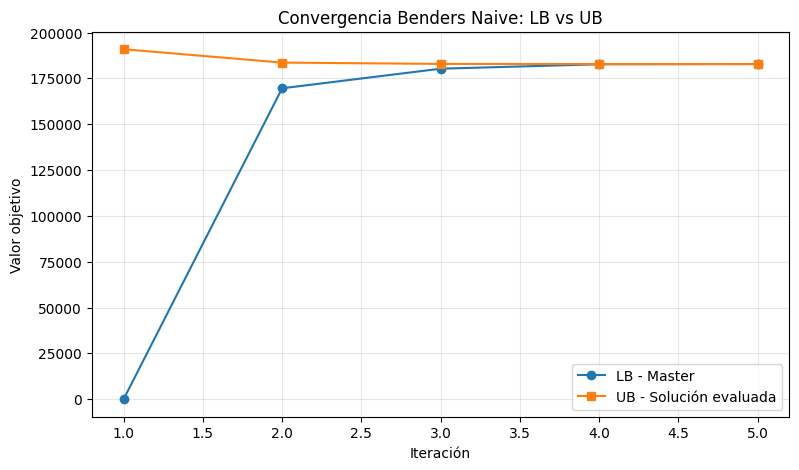

In [79]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(benders_results["LB_history"]) + 1),
    benders_results["LB_history"],
    marker="o",
    label="LB - Master"
)

plt.plot(
    range(1, len(benders_results["UB_history"]) + 1),
    benders_results["UB_history"],
    marker="s",
    label="UB - Solución evaluada"
)

plt.xlabel("Iteración")
plt.ylabel("Valor objetivo")
plt.title("Convergencia Benders Naive: LB vs UB")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2.3. Branch and Cut

In [121]:
def solve_benders_callback(base, omegas, p_omega, D, U_ew, c_ew, G_iw,
                           delta_u=DELTA_U, budget=BUDGET, pi=PI,
                           tol=1e-4, time_limit=None, verbose=True):
    """
    Implementación de Branch-and-Cut donde los cortes de Benders se añaden
    dinámicamente como lazy constraints cada vez que se encuentra una solución
    entera candidata.

    Ventajas:
        - Integración completa con el árbol de Branch & Bound de Gurobi.
        - Los cortes se añaden solo cuando son violados.
        - Se controla la duplicación de cortes y el uso de memoria.
    """
    start_time = time.time()
    edges_list = base["edges_list"]
    H_e = base["H_e"]

    # Modelo maestro (relajado, con variables auxiliares z_w)
    m = gp.Model("Benders_Callback")
    m.Params.LazyConstraints = 1  # Habilitar lazy constraints
    # Parámetros para mejorar estabilidad numérica y reducir memoria
    m.Params.MIPFocus = 1 # Enfocar en mejorar la cota inferior
    m.Params.Cuts = 0 # Desactivar cortes automáticos (solo los nuestros)
    m.Params.Presolve = 2 # Presolve más agresivo
    m.Params.Threads = 4 # Limitar número de hilos
    if not verbose:
        m.Params.OutputFlag = 0
    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # Variables de primera etapa
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    # Variables auxiliares para aproximar el costo de segunda etapa
    z = m.addVars(omegas, lb=0, name="z")
    
    # Fuerza al menos un arco reforzado (evita solución trivial)
    # m.addConstr(gp.quicksum(h[e] for e in edges_list) >= 1, name="min_one_arc")

    # Restricción de presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # Función objetivo
    m.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) +
        gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    # Almacenar datos necesarios en el modelo para ser accesibles desde el callback
    m._h = h
    m._z = z
    m._edges_list = edges_list
    m._omegas = omegas
    m._p_omega = p_omega
    m._base = base
    m._D = D
    m._U_ew = U_ew
    m._c_ew = c_ew
    m._G_iw = G_iw
    m._delta_u = delta_u
    m._pi = pi
    m._tol = tol
    m._cuts = 0 # Contador global de cortes añadidos
    m._added_cuts = set() # Conjunto para evitar cortes duplicados
    m._incumbent_log = [] # Para registrar información de cada solución entera

    # Callback que se ejecuta cada vez que Gurobi encuentra una solución entera
    def benders_lazy_callback(model, where):
        if where == GRB.Callback.MIPSOL:
            # Obtener la solución candidata (valores de h y z)
            h_sol = {
                e: round(model.cbGetSolution(model._h[e]))
                for e in model._edges_list
            }
            z_sol = {
                w: model.cbGetSolution(model._z[w])
                for w in model._omegas
            }

            cuts_this_solution = 0
            evaluated_second_stage = 0

            # Evaluar la solución candidata en todos los escenarios
            for w in model._omegas:
                sp_res = solve_second_stage(
                    w, h_sol, model._base,
                    model._D, model._U_ew, model._c_ew, model._G_iw,
                    model._delta_u, model._pi, verbose=False
                )
                if sp_res is None:
                    continue

                Q_w = sp_res["objective"]
                dual_cap = sp_res["dual_cap"]
                evaluated_second_stage += model._p_omega[w] * Q_w

                # Si la aproximación actual es menor que el costo real, añadir corte
                if z_sol[w] < Q_w - model._tol:
                    
                    #print(f"Adding cut for w={w}: z={z_sol[w]:.2f} < Q={Q_w:.2f}")
                    
                    # Construir corte clásico de Benders
                    expr = Q_w + gp.quicksum(
                        (dual_cap[e]) * model._U_ew[w, e] * model._delta_u *
                        (model._h[e] - h_sol[e])
                        for e in model._edges_list
                    )
                    # Clave única para evitar duplicados (escenario + solución h_sol)
                    key = (w, tuple(sorted((e, h_sol[e]) for e in model._edges_list)))
                    if key not in model._added_cuts:
                        model.cbLazy(model._z[w] >= expr)
                        model._added_cuts.add(key)
                        model._cuts += 1
                        cuts_this_solution += 1

            # Registrar información de esta solución entera
            investment_cost = sum(model._base["H_e"][e] * h_sol[e]
                                  for e in model._edges_list)
            model._incumbent_log.append({
                "investment_cost": investment_cost,
                "expected_second_stage": evaluated_second_stage,
                "evaluated_total_cost": investment_cost + evaluated_second_stage,
                "cuts_added": cuts_this_solution
            })

    # Resolver el modelo con el callback
    m.optimize(benders_lazy_callback)
    runtime = time.time() - start_time

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Modelo callback no óptimo. Status:", m.Status)
        return None

    # Solución final de primera etapa
    h_sol = {e: round(h[e].X) for e in edges_list}

    # Evaluación final de la solución (costo esperado real)
    eval_final = evaluate_solution(
        h_hat=h_sol, base=base, omegas=omegas, p_omega=p_omega,
        D=D, U_ew=U_ew, c_ew=c_ew, G_iw=G_iw,
        delta_u=delta_u, pi=pi
    )

    return {
        "objective": eval_final["total_expected_cost"],
        "master_objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "best_h": h_sol,
        "selected_edges": [e for e in edges_list if h_sol[e] > 0.5],
        "num_selected_edges": sum(h_sol[e] for e in edges_list),
        "investment_cost": eval_final["investment_cost"],
        "expected_second_stage": eval_final["expected_second_stage"],
        "total_cuts": m._cuts,
        "incumbent_log": pd.DataFrame(m._incumbent_log),
        "model": m
    }

In [122]:
callback_results = solve_benders_callback(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    tol=1e-4,
    verbose=True
)

print("RESULTADOS BRANCH-AND-CUT")
print("Objetivo evaluado:", callback_results["objective"])
print("Objetivo master:", callback_results["master_objective"])
print("Tiempo:", callback_results["runtime"])
print("Cortes agregados:", callback_results["total_cuts"])
print("Costo inversión:", callback_results["investment_cost"])
print("Costo esperado segunda etapa:", callback_results["expected_second_stage"])
print("Arcos reforzados:", callback_results["num_selected_edges"])
print("Lista de arcos reforzados:", callback_results["selected_edges"])

Set parameter LazyConstraints to value 1
Set parameter MIPFocus to value 1
Set parameter Cuts to value 0
Set parameter Presolve to value 2
Set parameter Threads to value 4
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 5600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 4 threads

Non-default parameters:
MIPFocus  1
Cuts  0
Presolve  2
Threads  4
LazyConstraints  1

Optimize a model with 1 rows, 189 columns and 179 nonzeros
Model fingerprint: 0xfaf9f4ee
Variable types: 10 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [5e+01, 5e+01]
  Objective range  [1e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e+03, 3e+03]
Found heuristic solution: objective 0.0000000

Explored 0 nodes (0 simplex iterations) in 0.41 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution count 1: 0 


In [119]:
callback_results

{'objective': 190880.80428647695,
 'master_objective': 0.0,
 'runtime': 0.4573862552642822,
 'h_sol': {0: 0,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  9: 0,
  10: 0,
  11: 0,
  12: 0,
  13: 0,
  14: 0,
  15: 0,
  16: 0,
  17: 0,
  18: 0,
  19: 0,
  20: 0,
  21: 0,
  22: 0,
  23: 0,
  24: 0,
  25: 0,
  26: 0,
  27: 0,
  28: 0,
  29: 0,
  30: 0,
  31: 0,
  32: 0,
  33: 0,
  34: 0,
  35: 0,
  36: 0,
  37: 0,
  38: 0,
  39: 0,
  40: 0,
  41: 0,
  42: 0,
  43: 0,
  44: 0,
  45: 0,
  46: 0,
  47: 0,
  48: 0,
  49: 0,
  50: 0,
  51: 0,
  52: 0,
  53: 0,
  54: 0,
  55: 0,
  56: 0,
  57: 0,
  58: 0,
  59: 0,
  60: 0,
  61: 0,
  62: 0,
  63: 0,
  64: 0,
  65: 0,
  66: 0,
  67: 0,
  68: 0,
  69: 0,
  70: 0,
  71: 0,
  72: 0,
  73: 0,
  74: 0,
  75: 0,
  76: 0,
  77: 0,
  78: 0,
  79: 0,
  80: 0,
  81: 0,
  82: 0,
  83: 0,
  84: 0,
  85: 0,
  86: 0,
  87: 0,
  88: 0,
  89: 0,
  90: 0,
  91: 0,
  92: 0,
  93: 0,
  94: 0,
  95: 0,
  96: 0,
  97: 0,
  98: 0,
  99: 0,
  100: 0,

## 2.3.1 B&C 0.5

In [124]:
def generate_combinatorial_cut_p2(h_hat, Q_w, h_vars, z_var, edges_list):
    """
    Genera un corte combinatorio de Benders para el proyecto P2.

    Este corte sigue la misma lógica del ejemplo de clase:

        Si h es exactamente igual a h_hat:
            z_w >= Q_w

        Si h cambia respecto a h_hat:
            el corte se relaja y deja de ser restrictivo.

    Parámetros:
    - h_hat: solución candidata de primera etapa {e: 0/1}
    - Q_w: costo real del subproblema para el escenario w
    - h_vars: variables binarias h[e] del master
    - z_var: variable z[w] asociada al escenario w
    - edges_list: lista de arcos

    Retorna:
    - una expresión tipo constraint para usar en cbLazy.
    """

    # Arcos reforzados en la solución candidata
    ones = [e for e in edges_list if h_hat[e] >= 0.5]

    # Arcos no reforzados en la solución candidata
    zeros = [e for e in edges_list if h_hat[e] < 0.5]

    # Esta expresión vale 1 cuando h == h_hat.
    # Si alguna variable cambia, la expresión baja.
    match_expr = 1

    # Si un arco que estaba en 1 pasa a 0, se penaliza
    match_expr -= gp.quicksum(1 - h_vars[e] for e in ones)

    # Si un arco que estaba en 0 pasa a 1, se penaliza
    match_expr -= gp.quicksum(h_vars[e] for e in zeros)

    # Corte combinatorio:
    # cuando h == h_hat, obliga z_w >= Q_w.
    # cuando h != h_hat, se relaja.
    return z_var >= Q_w * match_expr

In [125]:
def benders_callback_p2(model, where):
    """
    Callback de Branch-and-Cut para el proyecto P2.

    Se ejecuta cada vez que Gurobi encuentra una solución entera candidata
    del master. En ese momento:

    1. Extrae h_hat y z_hat.
    2. Resuelve los subproblemas de segunda etapa por escenario.
    3. Si z_w subestima Q_w(h_hat), agrega un corte lazy combinatorio.
    """

    # Solo actuamos cuando Gurobi encuentra una solución entera candidata
    if where == GRB.Callback.MIPSOL:

        # -----------------------------
        # 1. Extraer solución candidata
        # -----------------------------

        h_hat = {
            e: round(model.cbGetSolution(model._h[e]))
            for e in model._edges_list
        }

        z_hat = {
            w: model.cbGetSolution(model._z[w])
            for w in model._omegas
        }

        cuts_this_solution = 0
        expected_second_stage = 0

        # -----------------------------
        # 2. Resolver subproblemas
        # -----------------------------

        for w in model._omegas:

            sp_res = solve_second_stage(
                w=w,
                h_hat=h_hat,
                base=model._base,
                D=model._D,
                U_ew=model._U_ew,
                c_ew=model._c_ew,
                G_iw=model._G_iw,
                delta_u=model._delta_u,
                pi=model._pi,
                verbose=False
            )

            if sp_res is None:
                continue

            Q_w = sp_res["objective"]
            expected_second_stage += model._p_omega[w] * Q_w

            # -----------------------------
            # 3. Agregar lazy cut si hace falta
            # -----------------------------

            if z_hat[w] < Q_w - model._tol:

                # Evitar repetir exactamente el mismo corte
                key = (
                    w,
                    tuple((e, h_hat[e]) for e in model._edges_list)
                )

                if key not in model._added_cuts:

                    lazy_cut = generate_combinatorial_cut_p2(
                        h_hat=h_hat,
                        Q_w=Q_w,
                        h_vars=model._h,
                        z_var=model._z[w],
                        edges_list=model._edges_list
                    )

                    model.cbLazy(lazy_cut)

                    model._added_cuts.add(key)
                    model._cuts += 1
                    cuts_this_solution += 1

        # -----------------------------
        # 4. Guardar log de la solución candidata
        # -----------------------------

        investment_cost = sum(
            model._H_e[e] * h_hat[e]
            for e in model._edges_list
        )

        model._incumbent_log.append({
            "investment_cost": investment_cost,
            "expected_second_stage": expected_second_stage,
            "evaluated_total_cost": investment_cost + expected_second_stage,
            "cuts_added": cuts_this_solution
        })

In [126]:
def solve_benders_callback(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    tol=1e-4,
    time_limit=None,
    verbose=True
):
    """
    Resuelve el problema del proyecto P2 usando Branch-and-Cut
    con cortes combinatorios lazy, siguiendo la estructura del ejemplo de clase.

    Master:
        min sum_e H_e h_e + sum_w p_w z_w

    sujeto a:
        presupuesto
        h_e binaria
        z_w >= aproximación del costo de segunda etapa

    Los cortes sobre z_w se agregan dinámicamente dentro del callback.
    """

    start_time = time.time()

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    # -----------------------------
    # 1. Crear modelo master
    # -----------------------------

    m = gp.Model("Benders_Branch_and_Cut_P2")

    if not verbose:
        m.Params.OutputFlag = 0

    # Activar lazy constraints
    m.Params.LazyConstraints = 1

    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # -----------------------------
    # 2. Variables del master
    # -----------------------------

    # h[e] = 1 si se refuerza el arco e
    h = m.addVars(
        edges_list,
        vtype=GRB.BINARY,
        name="h"
    )

    # z[w] aproxima el costo de segunda etapa en el escenario w
    z = m.addVars(
        omegas,
        lb=0,
        vtype=GRB.CONTINUOUS,
        name="z"
    )

    # -----------------------------
    # 3. Restricción de presupuesto
    # -----------------------------

    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    # -----------------------------
    # 4. Función objetivo del master
    # -----------------------------

    m.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list)
        + gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    # -----------------------------
    # 5. Adjuntar datos al modelo
    # -----------------------------
    # Esto es igual a lo que hace el ejemplo de clase con:
    # m._inst, m._x, m._z, etc.

    m._h = h
    m._z = z
    m._edges_list = edges_list
    m._omegas = omegas
    m._p_omega = p_omega

    m._base = base
    m._D = D
    m._U_ew = U_ew
    m._c_ew = c_ew
    m._G_iw = G_iw

    m._delta_u = delta_u
    m._pi = pi
    m._tol = tol
    m._H_e = H_e

    # Contadores y logs
    m._cuts = 0
    m._added_cuts = set()
    m._incumbent_log = []

    # -----------------------------
    # 6. Optimizar con callback
    # -----------------------------

    m.optimize(benders_callback_p2)

    runtime = time.time() - start_time

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Modelo Branch-and-Cut no óptimo. Status:", m.Status)
        return None

    # -----------------------------
    # 7. Extraer solución final
    # -----------------------------

    h_sol = {
        e: round(h[e].X)
        for e in edges_list
    }

    selected_edges = [
        e for e in edges_list
        if h_sol[e] > 0.5
    ]

    # Evaluar solución final en los escenarios reales
    eval_final = evaluate_solution(
        h_hat=h_sol,
        base=base,
        omegas=omegas,
        p_omega=p_omega,
        D=D,
        U_ew=U_ew,
        c_ew=c_ew,
        G_iw=G_iw,
        delta_u=delta_u,
        pi=pi,
        verbose=False
    )

    # -----------------------------
    # 8. Retornar resultados
    # -----------------------------

    results = {
        "model": m,
        "objective": eval_final["total_expected_cost"],
        "master_objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "best_h": h_sol,
        "selected_edges": selected_edges,
        "num_selected_edges": len(selected_edges),
        "investment_cost": eval_final["investment_cost"],
        "expected_second_stage": eval_final["expected_second_stage"],
        "total_cuts": m._cuts,
        "incumbent_log": pd.DataFrame(m._incumbent_log),
        "scenario_costs": eval_final["scenario_costs"]
    }

    return results

In [127]:
callback_results = solve_benders_callback(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    tol=1e-4,
    time_limit=300,
    verbose=True
)

print("\n========== RESULTADOS BRANCH-AND-CUT ==========")
print("Objetivo evaluado:", callback_results["objective"])
print("Objetivo master:", callback_results["master_objective"])
print("Tiempo:", callback_results["runtime"])
print("Cortes agregados:", callback_results["total_cuts"])
print("Costo inversión:", callback_results["investment_cost"])
print("Costo esperado segunda etapa:", callback_results["expected_second_stage"])
print("Arcos reforzados:", callback_results["num_selected_edges"])
print("Lista de arcos reforzados:", callback_results["selected_edges"])

Set parameter LazyConstraints to value 1
Set parameter TimeLimit to value 300
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 5600U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  300
LazyConstraints  1

Optimize a model with 1 rows, 189 columns and 179 nonzeros
Model fingerprint: 0xfaf9f4ee
Variable types: 10 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [5e+01, 5e+01]
  Objective range  [1e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e+03, 3e+03]
Found heuristic solution: objective 0.0000000

Explored 0 nodes (0 simplex iterations) in 0.46 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution count 1: 0 

Optimal solution found (tolerance 1.00e-04)
Best objective 0.000000000000e+00, best bound 0.000000000000e+00, gap 0.0000

## 2.4. Comparación estrategias de solución

In [123]:
comparison_algorithms = pd.DataFrame([
    {
        "Método": "Deterministic Equivalent",
        "Objetivo": de_results["objective"],
        "Tiempo (s)": de_results["runtime"],
        "Iteraciones / cortes": "-",
        "Arcos reforzados": de_results["num_selected_edges"]
    },
    {
        "Método": "Benders Naive",
        "Objetivo": benders_results["objective"],
        "Tiempo (s)": benders_results["runtime"],
        "Iteraciones / cortes": f'{benders_results["iterations"]} iter / {benders_results["total_cuts"]} cortes',
        "Arcos reforzados": benders_results["num_selected_edges"]
    },
    {
        "Método": "Branch-and-Cut",
        "Objetivo": callback_results["objective"],
        "Tiempo (s)": callback_results["runtime"],
        "Iteraciones / cortes": f'{callback_results["total_cuts"]} cortes',
        "Arcos reforzados": callback_results["num_selected_edges"]
    }
])

comparison_algorithms

,Método,Objetivo,Tiempo (s),Iteraciones / cortes,Arcos reforzados
0,Deterministic Equivalent,182798.651774,2.206832,-,11
1,Benders Naive,182787.944265,1.270457,5 iter / 29 cortes,11
2,Branch-and-Cut,190880.804286,0.443738,10 cortes,0


## comparativas

In [128]:
print("========== COMPARACIÓN DE OBJETIVOS ==========")

obj_ed = de_results["objective"]
obj_bn = benders_results["objective"]
obj_bc = callback_results["objective"]

print("ED:", obj_ed)
print("Benders Naive:", obj_bn)
print("Branch-and-Cut:", obj_bc)

print("\n========== DIFERENCIAS ABSOLUTAS ==========")
print("ED vs Benders Naive:", abs(obj_ed - obj_bn))
print("ED vs Branch-and-Cut:", abs(obj_ed - obj_bc))
print("Benders Naive vs Branch-and-Cut:", abs(obj_bn - obj_bc))

print("\n========== DIFERENCIAS RELATIVAS ==========")
print("ED vs Benders Naive:", abs(obj_ed - obj_bn) / max(1, abs(obj_ed)))
print("ED vs Branch-and-Cut:", abs(obj_ed - obj_bc) / max(1, abs(obj_ed)))
print("Benders Naive vs Branch-and-Cut:", abs(obj_bn - obj_bc) / max(1, abs(obj_bn)))

========== COMPARACIÓN DE OBJETIVOS ==========
ED: 182798.65177398775
Benders Naive: 182787.94426485343
Branch-and-Cut: 190880.80428647695

========== DIFERENCIAS ABSOLUTAS ==========
ED vs Benders Naive: 10.707509134314023
ED vs Branch-and-Cut: 8082.152512489207
Benders Naive vs Branch-and-Cut: 8092.860021623521

========== DIFERENCIAS RELATIVAS ==========
ED vs Benders Naive: 5.857542728243306e-05
ED vs Branch-and-Cut: 0.044213414235034845
Benders Naive vs Branch-and-Cut: 0.044274583064938054


In [129]:
print("========== STATUS DE LOS MODELOS ==========")

try:
    print("ED status:", de_results["model"].Status)
except:
    print("ED: no se encontró model en de_results")

try:
    print("Benders Naive status:", benders_results["master_model"].Status)
except:
    print("Benders Naive: no se encontró master_model")

try:
    print("Branch-and-Cut status:", callback_results["model"].Status)
except:
    print("Branch-and-Cut: no se encontró model en callback_results")

========== STATUS DE LOS MODELOS ==========
ED status: 2
Benders Naive status: 2
Branch-and-Cut status: 2


In [130]:
obj_ed = de_results["objective"]
obj_bn = benders_results["objective"]
obj_bc = callback_results["objective"]

print("ED:", obj_ed)
print("Benders Naive:", obj_bn)
print("Branch-and-Cut:", obj_bc)

print("\nDiferencia ED vs BN:", abs(obj_ed - obj_bn))
print("Diferencia ED vs BC:", abs(obj_ed - obj_bc))
print("Diferencia BN vs BC:", abs(obj_bn - obj_bc))

print("\nDiferencia relativa ED vs BN:", abs(obj_ed - obj_bn) / max(1, abs(obj_ed)))
print("Diferencia relativa ED vs BC:", abs(obj_ed - obj_bc) / max(1, abs(obj_ed)))

ED: 182798.65177398775
Benders Naive: 182787.94426485343
Branch-and-Cut: 190880.80428647695

Diferencia ED vs BN: 10.707509134314023
Diferencia ED vs BC: 8082.152512489207
Diferencia BN vs BC: 8092.860021623521

Diferencia relativa ED vs BN: 5.857542728243306e-05
Diferencia relativa ED vs BC: 0.044213414235034845


In [131]:
print("Arcos ED:", sorted(de_results["selected_edges"]))
print("Arcos BN:", sorted(benders_results["selected_edges"]))
print("Arcos BC:", sorted(callback_results["selected_edges"]))

print("\n¿ED = BN?", set(de_results["selected_edges"]) == set(benders_results["selected_edges"]))
print("¿ED = BC?", set(de_results["selected_edges"]) == set(callback_results["selected_edges"]))
print("¿BN = BC?", set(benders_results["selected_edges"]) == set(callback_results["selected_edges"]))

Arcos ED: [15, 17, 22, 41, 48, 58, 59, 63, 69, 93, 94]
Arcos BN: [15, 17, 22, 41, 48, 58, 59, 63, 69, 93, 94]
Arcos BC: []

¿ED = BN? True
¿ED = BC? False
¿BN = BC? False


In [132]:
print("Master objective BC:", callback_results["master_objective"])
print("Evaluated objective BC:", callback_results["objective"])
print("Diferencia:", abs(callback_results["master_objective"] - callback_results["objective"]))

Master objective BC: 0.0
Evaluated objective BC: 190880.80428647695
Diferencia: 190880.80428647695


## 3. Escalabilidad: SAA y efecto del número de escenarios N

En esta sección se analiza la estabilidad de la solución estocástica cuando cambia el número de escenarios utilizados en la aproximación SAA.

Para cada valor de N se generan varias réplicas independientes. Luego, para cada réplica, se resuelve el problema y se registran:

- valor objetivo,
- tiempo computacional,
- número de arcos reforzados.

Este experimento permite observar si la solución se estabiliza al aumentar N y cómo crece el esfuerzo computacional.

In [154]:
def run_scalability_experiment(
    N_values=[10, 25, 50],
    M=5,
    method="callback",
    seed_base=123
):
    """
    Ejecuta un experimento SAA.

    Para cada tamaño N:
    - genera M muestras independientes de escenarios,
    - resuelve el problema,
    - guarda objetivo, tiempo y número de arcos reforzados.

    method puede ser:
    - "callback"
    - "naive"
    - "de"
    """

    rows = []

    for N in N_values:
        print(f"\nN = {N}")

        for rep in range(1, M + 1):

            # Semilla diferente para cada réplica
            seed = seed_base + 1000 * N + rep

            # Generamos escenarios
            dfD_N, dfU_N, dfc_N, dfG_N, dfp_N = generate_scenarios_table(
                nodes,
                edges,
                N=N,
                seed=seed
            )

            # Convertimos tablas a diccionarios
            omegas_N, p_omega_N, D_N, U_ew_N, c_ew_N, G_iw_N = build_scenario_data(
                dfD_N,
                dfU_N,
                dfc_N,
                dfG_N,
                dfp_N
            )

            start = time.time()

            # Seleccionamos método de solución
            if method == "callback":
                res = solve_benders_callback(
                    base=base,
                    omegas=omegas_N,
                    p_omega=p_omega_N,
                    D=D_N,
                    U_ew=U_ew_N,
                    c_ew=c_ew_N,
                    G_iw=G_iw_N,
                    verbose=False,
                    time_limit=300
                )

            elif method == "naive":
                res = solve_benders_naive(
                    base=base,
                    omegas=omegas_N,
                    p_omega=p_omega_N,
                    D=D_N,
                    U_ew=U_ew_N,
                    c_ew=c_ew_N,
                    G_iw=G_iw_N,
                    verbose=False,
                    max_iter=100,
                    time_limit=300
                )

            elif method == "de":
                res = solve_deterministic_equivalent(
                    base=base,
                    omegas=omegas_N,
                    p_omega=p_omega_N,
                    D=D_N,
                    U_ew=U_ew_N,
                    c_ew=c_ew_N,
                    G_iw=G_iw_N,
                    verbose=False,
                    time_limit=300
                )

            else:
                raise ValueError("method debe ser: 'callback', 'naive' o 'de'")

            runtime = time.time() - start

            rows.append({
                "N": N,
                "replica": rep,
                "method": method,
                "objective": res["objective"],
                "runtime": runtime,
                "num_selected_edges": res["num_selected_edges"]
            })

            print(
                f"Rep {rep}/{M} | Obj={res['objective']:.2f} | "
                f"Tiempo={runtime:.2f}s | Arcos={res['num_selected_edges']}"
            )

    return pd.DataFrame(rows)

In [155]:
df_scalability = run_scalability_experiment(
    N_values=[10, 25, 50],
    M=5,
    method="naive",
    seed_base=SEED_BASE
)

df_scalability


N = 10


C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[121.95 121.95 142.2  142.2  121.95  93.15 144.   141.75 121.95 122.85
  94.5  135.    72.   113.4  114.75  80.1  136.8  117.9  113.4  107.55
 142.2  555.3   70.2  117.9  128.7  152.1  121.5  141.75 121.95 150.3
 113.4   79.2  129.6  121.95 141.75 137.7  121.95 642.15]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[122.85 121.95 121.95 121.95  93.15 144.   143.1  121.5  142.2  117.9
 121.95 122.85 121.95 135.   134.1  134.1  125.55 117.9  142.2  240.3
 142.2   70.2  134.1  121.95 140.85 141.75 121.5  

Rep 1/5 | Obj=257447.18 | Tiempo=1.76s | Arcos=9


C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[141.75 575.1  121.95 121.95 144.   127.8  121.95 121.95 107.55 240.3
 150.3  142.2  555.3  117.9  121.5  126.   150.3  121.95 121.95 121.5
 119.7  142.2  142.2  123.75 124.65 142.2  642.15 113.85]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[142.2  121.95 132.75 127.8  135.   121.95 141.75 117.9  121.95 123.75
 111.6  113.4  134.1  143.1  125.55 113.4  107.55 150.3  142.2  240.3
 546.75 142.2  555.3  134.1  117.45 113.85 113.85 113.85 121.95 121.95
 128.7  119.7  150.3  142.2  142.2  123.75 124.65 

Rep 2/5 | Obj=196640.75 | Tiempo=0.98s | Arcos=8


...

C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[121.95 142.2  121.95 132.75 116.55 127.8  144.   121.95 143.1  127.8
 121.95 142.2  141.75 124.65 122.85 121.95 121.5   80.1  142.2  142.2
 142.2   82.35 137.7  117.45 121.95 121.5  150.3  142.2  142.2  123.75
 110.7  124.65 642.15]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[144.   127.8  150.3  121.95 121.95 122.85 114.75 134.1  113.4  142.2
 556.2  150.3   70.2  121.95 121.5  121.95 113.85 113.85  98.55 126.
 135.9  121.95 150.3  121.95 113.4  121.5  142.2  117.45 132.75 111.6
 124.65 109.35 14

Rep 4/5 | Obj=175184.16 | Tiempo=5.37s | Arcos=12


C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[121.95 122.85 121.95 132.75 121.95  93.15 121.95 121.95 144.   144.
 143.1  133.65 121.95 121.5  117.9  113.4  142.2  150.3  240.3  142.2
  82.35 134.1  121.95 113.85 121.95 150.3  121.95 119.7  150.3   79.2
 121.5  150.3  141.75 142.2  130.05 124.65 110.7  111.6  109.35 141.75]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\958750286.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[121.95 122.85 144.   140.85 133.65 121.95 124.65 128.7  121.95 113.4
 438.75 123.75 113.4  143.1  113.4  150.3  142.2  106.65 555.3   58.05
 140.85 113.85 126.   121.95 150.3  12

Rep 5/5 | Obj=267301.84 | Tiempo=4.55s | Arcos=12


,N,replica,method,objective,runtime,num_selected_edges
0,10,1,naive,257447.181321,1.764283,9
1,10,2,naive,196640.753681,0.984572,8
2,10,3,naive,270033.967176,0.824031,7
3,10,4,naive,234639.670902,1.429367,10
4,10,5,naive,204122.937812,1.151962,10
5,25,1,naive,326900.068044,2.283112,11
6,25,2,naive,209861.825526,3.708457,13
7,25,3,naive,183708.528023,2.336099,11
8,25,4,naive,180347.963341,3.431967,9
9,25,5,naive,220941.050143,2.804076,13


<Figure size 800x500 with 0 Axes>

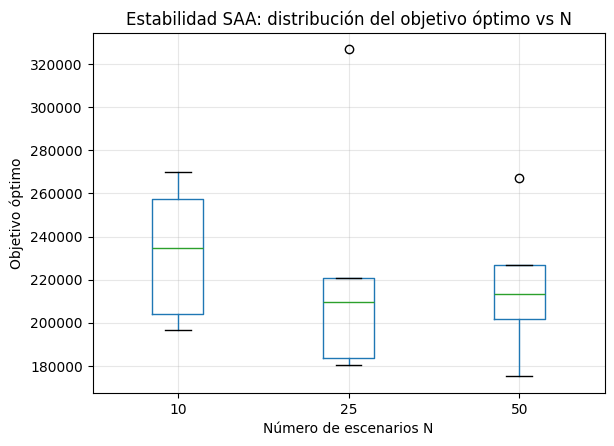

In [157]:
plt.figure(figsize=(8, 5))

df_scalability.boxplot(column="objective", by="N")

plt.title("Estabilidad SAA: distribución del objetivo óptimo vs N")
plt.suptitle("")
plt.xlabel("Número de escenarios N")
plt.ylabel("Objetivo óptimo")
plt.grid(alpha=0.3)
plt.show()

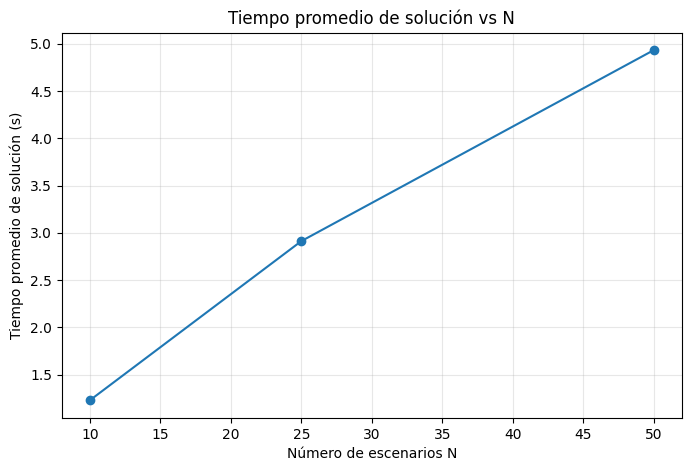

In [158]:

avg_time = df_scalability.groupby("N")["runtime"].mean().reset_index()

plt.figure(figsize=(8, 5))

plt.plot(
    avg_time["N"],
    avg_time["runtime"],
    marker="o"
)

plt.title("Tiempo promedio de solución vs N")
plt.xlabel("Número de escenarios N")
plt.ylabel("Tiempo promedio de solución (s)")
plt.grid(alpha=0.3)
plt.show()

## Latin hypercube sampling (FALTA)

## 4. Métricas de decisión: VSS, EVPI y CVaR

En esta sección se calculan métricas que permiten evaluar el valor de modelar explícitamente la incertidumbre.

- **RP:** costo óptimo del problema estocástico.
- **EEV:** costo esperado de usar la solución obtenida con parámetros promedio.
- **VSS:** valor de la solución estocástica.
- **WS:** solución Wait-and-See, donde se asume información perfecta.
- **EVPI:** valor esperado de la información perfecta.
- **CVaR:** medida de riesgo enfocada en los peores escenarios.

In [59]:
def build_expected_value_scenario(
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    base
):
    """
    Construye un escenario promedio.

    Este escenario usa:
    - demanda esperada,
    - capacidad esperada,
    - costo esperado,
    - generación esperada.

    Sirve para resolver el problema de valor esperado.
    """

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]

    D_ev = {}
    U_ev = {}
    c_ev = {}
    G_ev = {}

    # Demanda esperada por nodo
    for i in nodes_list:
        D_ev[(1, i)] = sum(p_omega[w] * D[w, i] for w in omegas)

    # Capacidad y costo esperado por arco
    for e in edges_list:
        U_ev[(1, e)] = sum(p_omega[w] * U_ew[w, e] for w in omegas)
        c_ev[(1, e)] = sum(p_omega[w] * c_ew[w, e] for w in omegas)

    # Generación esperada por nodo
    for i in nodes_list:
        G_ev[(1, i)] = sum(p_omega[w] * G_iw[w, i] for w in omegas)

    return [1], {1: 1.0}, D_ev, U_ev, c_ev, G_ev

In [60]:
# Creamos el escenario promedio
omegas_ev, p_ev, D_ev, U_ev, c_ev, G_ev = build_expected_value_scenario(
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    base=base
)

# Resolvemos el problema con valores esperados
ev_results = solve_deterministic_equivalent(
    base=base,
    omegas=omegas_ev,
    p_omega=p_ev,
    D=D_ev,
    U_ew=U_ev,
    c_ew=c_ev,
    G_iw=G_ev,
    verbose=False
)

# Solución obtenida con valores esperados
h_ev = ev_results["h_sol"]

# Evaluamos esa solución en todos los escenarios originales
eval_ev_on_stochastic = evaluate_solution(
    h_hat=h_ev,
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw
)

print("Objetivo problema EV:", ev_results["objective"])
print("EEV evaluado en escenarios:", eval_ev_on_stochastic["total_expected_cost"])
print("Solución EV arcos reforzados:", ev_results["selected_edges"])

Objetivo problema EV: 146167.73171594553
EEV evaluado en escenarios: 183959.74118513145
Solución EV arcos reforzados: [58, 59, 63, 69, 93]


In [61]:
def compute_wait_and_see(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    verbose=False
):
    """
    Calcula la solución Wait-and-See.

    Wait-and-See significa resolver cada escenario como si se conociera
    de antemano cuál escenario ocurrirá.

    Luego se pondera el resultado por la probabilidad del escenario.
    """

    rows = []
    WS = 0

    for w in omegas:
        print(f"Resolviendo Wait-and-See escenario {w}...")

        # Creamos un problema de un solo escenario
        D_w = {(1, i): D[w, i] for i in base["nodes_list"]}
        U_w = {(1, e): U_ew[w, e] for e in base["edges_list"]}
        c_w = {(1, e): c_ew[w, e] for e in base["edges_list"]}
        G_w = {(1, i): G_iw[w, i] for i in base["nodes_list"]}

        # Resolvemos el DE para ese único escenario
        res_w = solve_deterministic_equivalent(
            base=base,
            omegas=[1],
            p_omega={1: 1.0},
            D=D_w,
            U_ew=U_w,
            c_ew=c_w,
            G_iw=G_w,
            verbose=verbose
        )

        # Acumulamos costo ponderado
        WS += p_omega[w] * res_w["objective"]

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "objective_ws": res_w["objective"],
            "selected_edges": res_w["selected_edges"],
            "num_selected_edges": res_w["num_selected_edges"]
        })

    return WS, pd.DataFrame(rows)

In [62]:
# RP: óptimo del problema estocástico
RP = de_results["objective"]

# EEV: costo esperado de usar solución del valor esperado
EEV = eval_ev_on_stochastic["total_expected_cost"]

# VSS: beneficio de usar modelo estocástico
VSS = EEV - RP

# WS: costo esperado con información perfecta
WS, df_ws = compute_wait_and_see(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    verbose=False
)

# EVPI: valor esperado de la información perfecta
EVPI = RP - WS

print("RP:", RP)
print("EEV:", EEV)
print("VSS = EEV - RP:", VSS)
print("WS:", WS)
print("EVPI = RP - WS:", EVPI)

df_ws

Resolviendo Wait-and-See escenario 1...
Resolviendo Wait-and-See escenario 2...
Resolviendo Wait-and-See escenario 3...
Resolviendo Wait-and-See escenario 4...
Resolviendo Wait-and-See escenario 5...
Resolviendo Wait-and-See escenario 6...
Resolviendo Wait-and-See escenario 7...
Resolviendo Wait-and-See escenario 8...
Resolviendo Wait-and-See escenario 9...
Resolviendo Wait-and-See escenario 10...
RP: 182798.65177398775
EEV: 183959.74118513145
VSS = EEV - RP: 1161.0894111437083
WS: 182415.1245954338
EVPI = RP - WS: 383.52717855395167


,omega,p_omega,objective_ws,selected_edges,num_selected_edges
0,1,0.1,128744.297856,"[41, 58, 63, 93]",4
1,2,0.1,134232.435000,"[17, 58, 59, 63, 93]",5
2,3,0.1,138935.190727,"[15, 17, 41, 58, 59, 63, 69, 93]",8
3,4,0.1,143002.173480,"[58, 69, 93, 94]",4
4,5,0.1,131952.266218,"[58, 93]",2
5,6,0.1,610655.499100,"[22, 41, 48]",3
6,7,0.1,132159.638657,"[58, 59, 63, 93, 94, 106]",6
7,8,0.1,135179.983258,"[58, 60, 93, 94]",4
8,9,0.1,136736.981119,"[59, 63, 69, 93, 94]",5
9,10,0.1,132552.780539,"[41, 58, 93]",3


In [63]:
def compute_var_cvar(costs, probs, beta=0.95):
    """
    Calcula VaR y CVaR para una distribución discreta de costos.

    VaR_beta:
    - percentil beta de la distribución de costos.

    CVaR_beta:
    - costo promedio en la cola de peores escenarios.
    """

    df = pd.DataFrame({
        "cost": costs,
        "prob": probs
    }).sort_values("cost").reset_index(drop=True)

    # Probabilidad acumulada
    df["cum_prob"] = df["prob"].cumsum()

    # VaR: primer costo donde se alcanza beta
    VaR = df.loc[df["cum_prob"] >= beta, "cost"].iloc[0]

    # Cola de peores escenarios
    tail = df[df["cost"] >= VaR].copy()

    # Promedio ponderado en la cola
    CVaR = (tail["cost"] * tail["prob"]).sum() / tail["prob"].sum()

    return VaR, CVaR

In [64]:
# Solución estocástica neutral al riesgo
h_sto = de_results["h_sol"]

# Evaluamos la solución estocástica
eval_sto = evaluate_solution(
    h_hat=h_sto,
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw
)

# Costos totales por escenario
costs_sto = eval_sto["scenario_costs"]["total_cost_scenario"].values
probs_sto = eval_sto["scenario_costs"]["p_omega"].values

# Calculamos VaR y CVaR al 95%
VaR95_sto, CVaR95_sto = compute_var_cvar(
    costs=costs_sto,
    probs=probs_sto,
    beta=ALPHA
)

print("VaR95 solución neutral:", VaR95_sto)
print("CVaR95 solución neutral:", CVaR95_sto)

VaR95 solución neutral: 611055.4990995629
CVaR95 solución neutral: 611055.4990995629


In [65]:
def solve_cvar_model(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    beta=ALPHA,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI,
    time_limit=None,
    verbose=True
):
    """
    Resuelve un modelo extensivo con criterio CVaR.

    En lugar de minimizar solamente el costo esperado,
    minimiza inversión + CVaR del costo de segunda etapa.

    Esto genera una solución más conservadora frente a escenarios extremos.
    """

    start = time.time()

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    m = gp.Model("CVaR_Model")

    if not verbose:
        m.Params.OutputFlag = 0

    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    # Variables de primera etapa
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")

    # Variables de segunda etapa
    f = m.addVars(omegas, edges_list, lb=0, name="f")
    delta = m.addVars(omegas, demand_nodes, lb=0, name="delta")
    g = m.addVars(omegas, gen_nodes, lb=0, name="g")

    # Variables del CVaR
    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    u = m.addVars(omegas, lb=0, name="u")

    # Presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    scenario_cost_expr = {}

    for w in omegas:

        # Capacidad de arcos
        for e in edges_list:
            m.addConstr(
                f[w, e] <= U_ew[w, e] * (1 + delta_u * h[e]),
                name=f"cap_w{w}_e{e}"
            )

        # Generación máxima
        for i in gen_nodes:
            m.addConstr(
                g[w, i] <= G_iw[w, i],
                name=f"gen_w{w}_i{i}"
            )

        # Déficit máximo igual a demanda
        for i in demand_nodes:
            m.addConstr(
                delta[w, i] <= D[w, i],
                name=f"delta_w{w}_i{i}"
            )

        # Balance nodal
        for i in nodes_list:

            inflow = gp.quicksum(f[w, e] for e in in_arcs[i])
            outflow = gp.quicksum(f[w, e] for e in out_arcs[i])

            if i in demand_nodes:
                m.addConstr(
                    inflow - outflow == D[w, i] - delta[w, i],
                    name=f"balance_demand_w{w}_i{i}"
                )

            elif i in gen_nodes:
                m.addConstr(
                    inflow - outflow == -g[w, i],
                    name=f"balance_gen_w{w}_i{i}"
                )

            else:
                m.addConstr(
                    inflow - outflow == 0,
                    name=f"balance_trans_w{w}_i{i}"
                )

        # Costo de segunda etapa en escenario w
        scenario_cost_expr[w] = (
            gp.quicksum(c_ew[w, e] * f[w, e] for e in edges_list)
            + pi * gp.quicksum(delta[w, i] for i in demand_nodes)
        )

        # Restricción auxiliar del CVaR:
        # u_w >= costo_w - eta
        m.addConstr(
            u[w] >= scenario_cost_expr[w] - eta,
            name=f"cvar_excess_w{w}"
        )

    # Inversión
    investment_cost = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    # Término CVaR
    cvar_term = eta + (1 / (1 - beta)) * gp.quicksum(
        p_omega[w] * u[w] for w in omegas
    )

    # Objetivo risk-averse
    m.setObjective(
        investment_cost + cvar_term,
        GRB.MINIMIZE
    )

    m.optimize()

    runtime = time.time() - start

    if m.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
        print("Modelo CVaR no óptimo. Status:", m.Status)
        return None

    h_sol = {e: h[e].X for e in edges_list}
    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    return {
        "model": m,
        "objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "num_selected_edges": len(selected_edges),
        "investment_cost": sum(H_e[e] * h_sol[e] for e in edges_list),
        "eta": eta.X,
        "beta": beta
    }

In [66]:
cvar_results_95 = solve_cvar_model(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    beta=ALPHA,
    verbose=False
)

print("Objetivo CVaR:", cvar_results_95["objective"])
print("Eta:", cvar_results_95["eta"])
print("Tiempo:", cvar_results_95["runtime"])
print("Arcos reforzados:", cvar_results_95["num_selected_edges"])
print("Lista:", cvar_results_95["selected_edges"])

Objetivo CVaR: 610655.4990995628
Eta: 610505.4990995628
Tiempo: 0.279630184173584
Arcos reforzados: 3
Lista: [22, 41, 48]


In [67]:
# Solución aversa al riesgo
h_risk = cvar_results_95["h_sol"]

# Evaluamos solución CVaR en los escenarios originales
eval_risk = evaluate_solution(
    h_hat=h_risk,
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw
)

# Calculamos VaR y CVaR de la solución CVaR
costs_risk = eval_risk["scenario_costs"]["total_cost_scenario"].values
probs_risk = eval_risk["scenario_costs"]["p_omega"].values

VaR95_risk, CVaR95_risk = compute_var_cvar(
    costs=costs_risk,
    probs=probs_risk,
    beta=ALPHA
)

comparison_risk = pd.DataFrame([
    {
        "Solución": "Neutral al riesgo",
        "Costo esperado": eval_sto["total_expected_cost"],
        "VaR95": VaR95_sto,
        "CVaR95": CVaR95_sto,
        "Inversión": eval_sto["investment_cost"],
        "Arcos reforzados": sum(1 for e in h_sto if h_sto[e] > 0.5)
    },
    {
        "Solución": "Risk-averse CVaR95",
        "Costo esperado": eval_risk["total_expected_cost"],
        "VaR95": VaR95_risk,
        "CVaR95": CVaR95_risk,
        "Inversión": eval_risk["investment_cost"],
        "Arcos reforzados": sum(1 for e in h_risk if h_risk[e] > 0.5)
    }
])

comparison_risk

,Solución,Costo esperado,VaR95,CVaR95,Inversión,Arcos reforzados
0,Neutral al riesgo,182787.944265,611055.4991,611055.4991,550.0,11
1,Risk-averse CVaR95,190179.139774,610655.4991,610655.4991,150.0,3


In [162]:
metrics_table = pd.DataFrame([
    {
        "Métrica": "RP",
        "Valor": RP,
        "Interpretación": "Costo óptimo del modelo estocástico neutral al riesgo."
    },
    {
        "Métrica": "EEV",
        "Valor": EEV,
        "Interpretación": "Costo esperado de usar la solución del problema de valor esperado."
    },
    {
        "Métrica": "VSS",
        "Valor": VSS,
        "Interpretación": "Valor de modelar explícitamente la incertidumbre."
    },
    {
        "Métrica": "WS",
        "Valor": WS,
        "Interpretación": "Costo esperado si se conociera cada escenario antes de decidir."
    },
    {
        "Métrica": "EVPI",
        "Valor": EVPI,
        "Interpretación": "Valor máximo que se pagaría por información perfecta."
    },
    {
        "Métrica": "VaR95 neutral",
        "Valor": VaR95_sto,
        "Interpretación": "Percentil 95 del costo de la solución neutral."
    },
    {
        "Métrica": "CVaR95 neutral",
        "Valor": CVaR95_sto,
        "Interpretación": "Costo promedio en el 5% de peores escenarios para la solución neutral."
    },
    {
        "Métrica": "VaR95 risk-averse",
        "Valor": VaR95_risk,
        "Interpretación": "Percentil 95 del costo de la solución aversa al riesgo."
    },
    {
        "Métrica": "CVaR95 risk-averse",
        "Valor": CVaR95_risk,
        "Interpretación": "Costo promedio en el 5% de peores escenarios para la solución CVaR."
    }
])

metrics_table

,Métrica,Valor,Interpretación
0,RP,182798.651774,Costo óptimo del modelo estocástico neutral al...
1,EEV,183959.741185,Costo esperado de usar la solución del problem...
2,VSS,1161.089411,Valor de modelar explícitamente la incertidumbre.
3,WS,182415.124595,Costo esperado si se conociera cada escenario ...
4,EVPI,383.527179,Valor máximo que se pagaría por información pe...
5,VaR95 neutral,611055.499100,Percentil 95 del costo de la solución neutral.
6,CVaR95 neutral,611055.499100,Costo promedio en el 5% de peores escenarios p...
7,VaR95 risk-averse,610655.499100,Percentil 95 del costo de la solución aversa a...
8,CVaR95 risk-averse,610655.499100,Costo promedio en el 5% de peores escenarios p...


## 5. Backtesting extendido

En esta sección se evalúan las soluciones obtenidas en un conjunto nuevo de escenarios fuera de muestra.

El objetivo es analizar qué tan robustas son las decisiones cuando se enfrentan a realizaciones nuevas del mundo W.

Se comparan:

- solución estocástica neutral al riesgo,
- solución de valor esperado,
- solución aversa al riesgo CVaR.

Para cada solución se calcula:

- costo promedio fuera de muestra,
- VaR95,
- CVaR95,
- déficit promedio,
- proporción de escenarios con déficit.

In [69]:
def run_backtesting(
    solutions_dict,
    N_out=200,
    seed=2026
):
    """
    Evalúa varias soluciones en un conjunto nuevo de escenarios.

    solutions_dict debe tener la forma:
    {
        "nombre_solucion": h_sol,
        ...
    }
    """

    # Generamos nuevos escenarios fuera de muestra
    dfD_out, dfU_out, dfc_out, dfG_out, dfp_out = generate_scenarios_table(
        nodes,
        edges,
        N=N_out,
        seed=seed
    )

    # Convertimos tablas a diccionarios
    omegas_out, p_out, D_out, U_out, c_out, G_out = build_scenario_data(
        dfD_out,
        dfU_out,
        dfc_out,
        dfG_out,
        dfp_out
    )

    rows = []

    # Evaluamos cada solución
    for sol_name, h_sol in solutions_dict.items():

        print(f"Evaluando solución: {sol_name}")

        eval_sol = evaluate_solution(
            h_hat=h_sol,
            base=base,
            omegas=omegas_out,
            p_omega=p_out,
            D=D_out,
            U_ew=U_out,
            c_ew=c_out,
            G_iw=G_out
        )

        df_costs = eval_sol["scenario_costs"]

        # Calculamos VaR y CVaR fuera de muestra
        VaR95, CVaR95 = compute_var_cvar(
            costs=df_costs["total_cost_scenario"].values,
            probs=df_costs["p_omega"].values,
            beta=ALPHA
        )

        # Déficit promedio
        avg_deficit = df_costs["total_deficit"].mean()

        # Proporción de escenarios donde hubo déficit
        violation_rate = (df_costs["total_deficit"] > 1e-6).mean()

        rows.append({
            "Solución": sol_name,
            "Costo promedio out-of-sample": eval_sol["total_expected_cost"],
            "VaR95": VaR95,
            "CVaR95": CVaR95,
            "Déficit promedio": avg_deficit,
            "Tasa de escenarios con déficit": violation_rate,
            "Inversión": eval_sol["investment_cost"]
        })

    return pd.DataFrame(rows)

In [70]:
solutions_to_test = {
    "x_sto_neutral": de_results["h_sol"],
    "x_EV": h_ev,
    "x_risk_CVaR95": h_risk
}

df_backtesting = run_backtesting(
    solutions_dict=solutions_to_test,
    N_out=200,
    seed=2026
)

df_backtesting

C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\688715757.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[121.95 141.75 142.2  144.   469.8  121.95 127.8  121.95 128.7  121.95
 134.1  121.5  113.4  143.1  113.4  150.3  106.65  82.35 152.1  117.45
 122.85 553.95 124.65  98.55 150.3  135.9  128.7   79.2  129.6  142.2
 130.05 110.7  111.6  121.95 621.9  634.05 642.15]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  U.loc[outage, "U_w"] = cap_drop * U.loc[outage, "U_base"]
C:\Users\sofia\AppData\Local\Temp\ipykernel_46576\688715757.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[575.1  121.95 121.95 116.55 144.   127.8  143.1  121.95 117.9  142.2
 135.   122.85 121.5   72.   114.75  80.1  134.1  128.7  117.45 140.85
 150.3   79.2  121.5  129.6  142.2  117.45 111.6  128.7 

Evaluando solución: x_sto_neutral
Evaluando solución: x_EV
Evaluando solución: x_risk_CVaR95


,Solución,Costo promedio out-of-sample,VaR95,CVaR95,Déficit promedio,Tasa de escenarios con déficit,Inversión
0,x_sto_neutral,199462.226662,713051.222153,757572.997785,738.473463,1.0,550.0
1,x_EV,199827.773160,712751.222153,757492.751572,743.904859,1.0,250.0
2,x_risk_CVaR95,207249.988679,712651.222153,758774.639598,782.562122,1.0,150.0


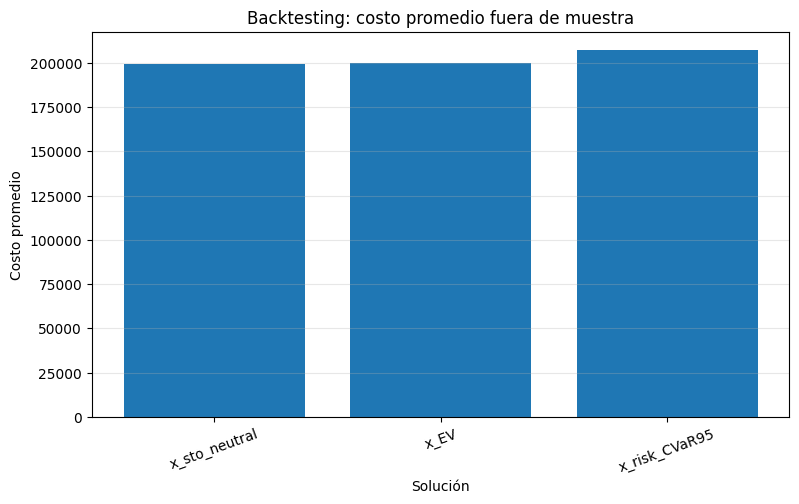

In [71]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_backtesting["Solución"],
    df_backtesting["Costo promedio out-of-sample"]
)

plt.title("Backtesting: costo promedio fuera de muestra")
plt.xlabel("Solución")
plt.ylabel("Costo promedio")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

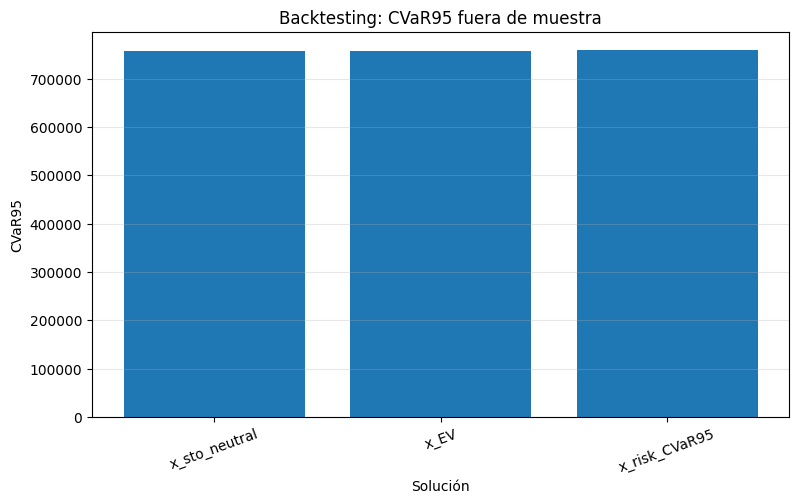

In [72]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_backtesting["Solución"],
    df_backtesting["CVaR95"]
)

plt.title("Backtesting: CVaR95 fuera de muestra")
plt.xlabel("Solución")
plt.ylabel("CVaR95")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

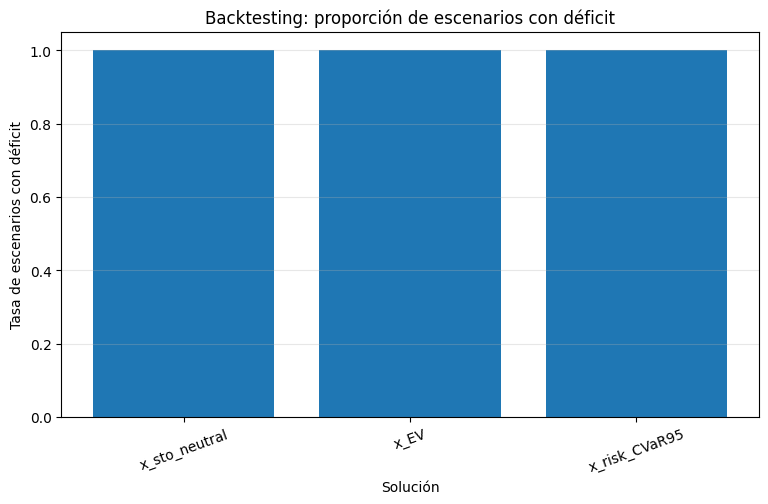

In [73]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_backtesting["Solución"],
    df_backtesting["Tasa de escenarios con déficit"]
)

plt.title("Backtesting: proporción de escenarios con déficit")
plt.xlabel("Solución")
plt.ylabel("Tasa de escenarios con déficit")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()